**From Aurelien Geron: Chapter 2 – End-to-end Machine Learning project**

*Our task is to predict median house values in Californian districts, given a number of features from these districts.*


## Setup

*   Link Google Drive (if working in Google Colab)
*   Import a few common modules
*   Add directory to save figures


In [1]:
# Python
import sys
assert sys.version_info >= (3, 7) # sys.version_info(major=3, minor=10, micro=12, releaselevel='final', serial=0)


# Scikit-Learn
from packaging import version
import sklearn
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

# Common imports
import pandas as pd
import numpy as np
import os

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

In [2]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [3]:
# Images will be saved in 'IMAGES_PATH'
PROJECT_ROOT_DIR = "/content/drive/MyDrive/courses/master_AI_ML/."
CHAPTER_ID = "end_to_end_project"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
# Create folder if it does not exist already
os.makedirs(IMAGES_PATH, exist_ok=True)

# Function to save figures in 'IMAGES_PATH', with name 'fig_id'.'fig_extension'
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

## Download the Data

In [5]:
path = 'https://github.com/iochoa/ml-datasets/raw/refs/heads/main/housing.csv'

housing = pd.read_csv(path)

More info here: https://www.kaggle.com/datasets/camnugent/california-housing-prices

## Take a Quick Look at the Data Structure

In [6]:
# Number of samples and features
housing.shape

(20640, 10)

The predictor variable is "median_house_value"

In [7]:
# take a look at the first 5 rows of the dataset
# use .head()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [8]:
housing.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [9]:
# to get more info about the features, we use the .info()
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


We observe that all features have 20640 values except the total_bedrooms feature!

What about the ocean_proximity feature?

In [47]:
# Check NaN values (we will take of them later)
housing.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,168
population,0
households,0
median_income,0
ocean_proximity,0
rooms_per_household,0


In [10]:
# We use the .value_counts() method to find out the categories and how many times each one appears.
housing["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [11]:
# We can use the .describe() method to get a summary of the numerical features.
# The null values are ignored for the calculations
housing.describe()

# do you understand what is plot in the table?

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Saving figure attribute_histogram_plots


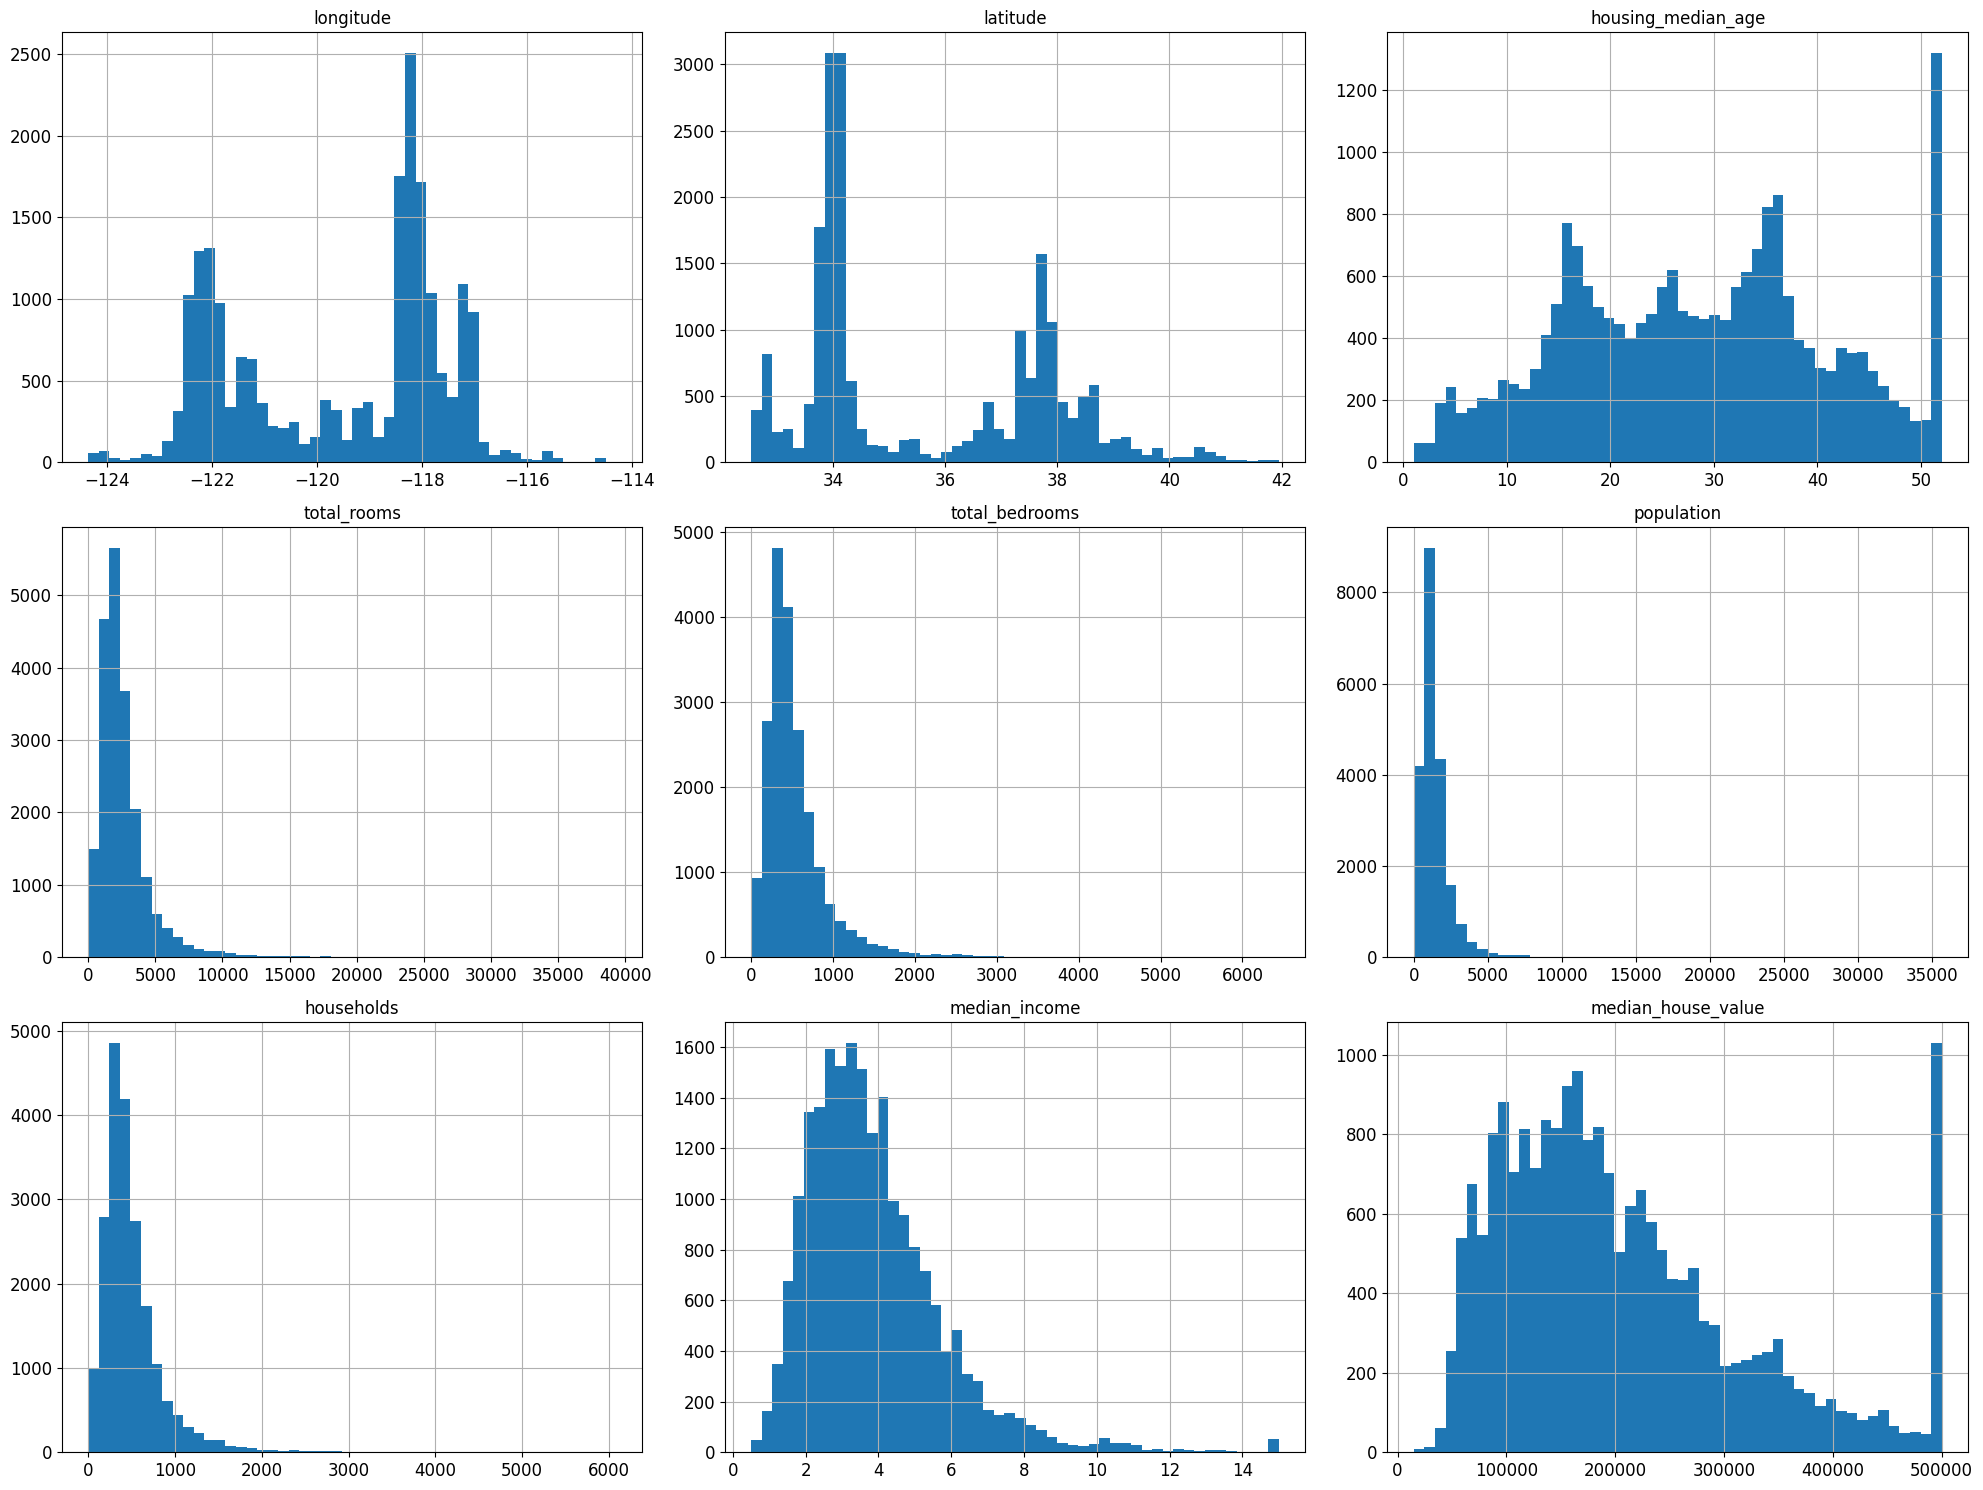

In [12]:
# You can also plot histograms for each numerical feature as well, which also gives useful information.
%matplotlib inline
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20,15))
save_fig("attribute_histogram_plots") # Check that the figure is indeed save in the appropriate folder.
plt.show()

array([[<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>]], dtype=object)

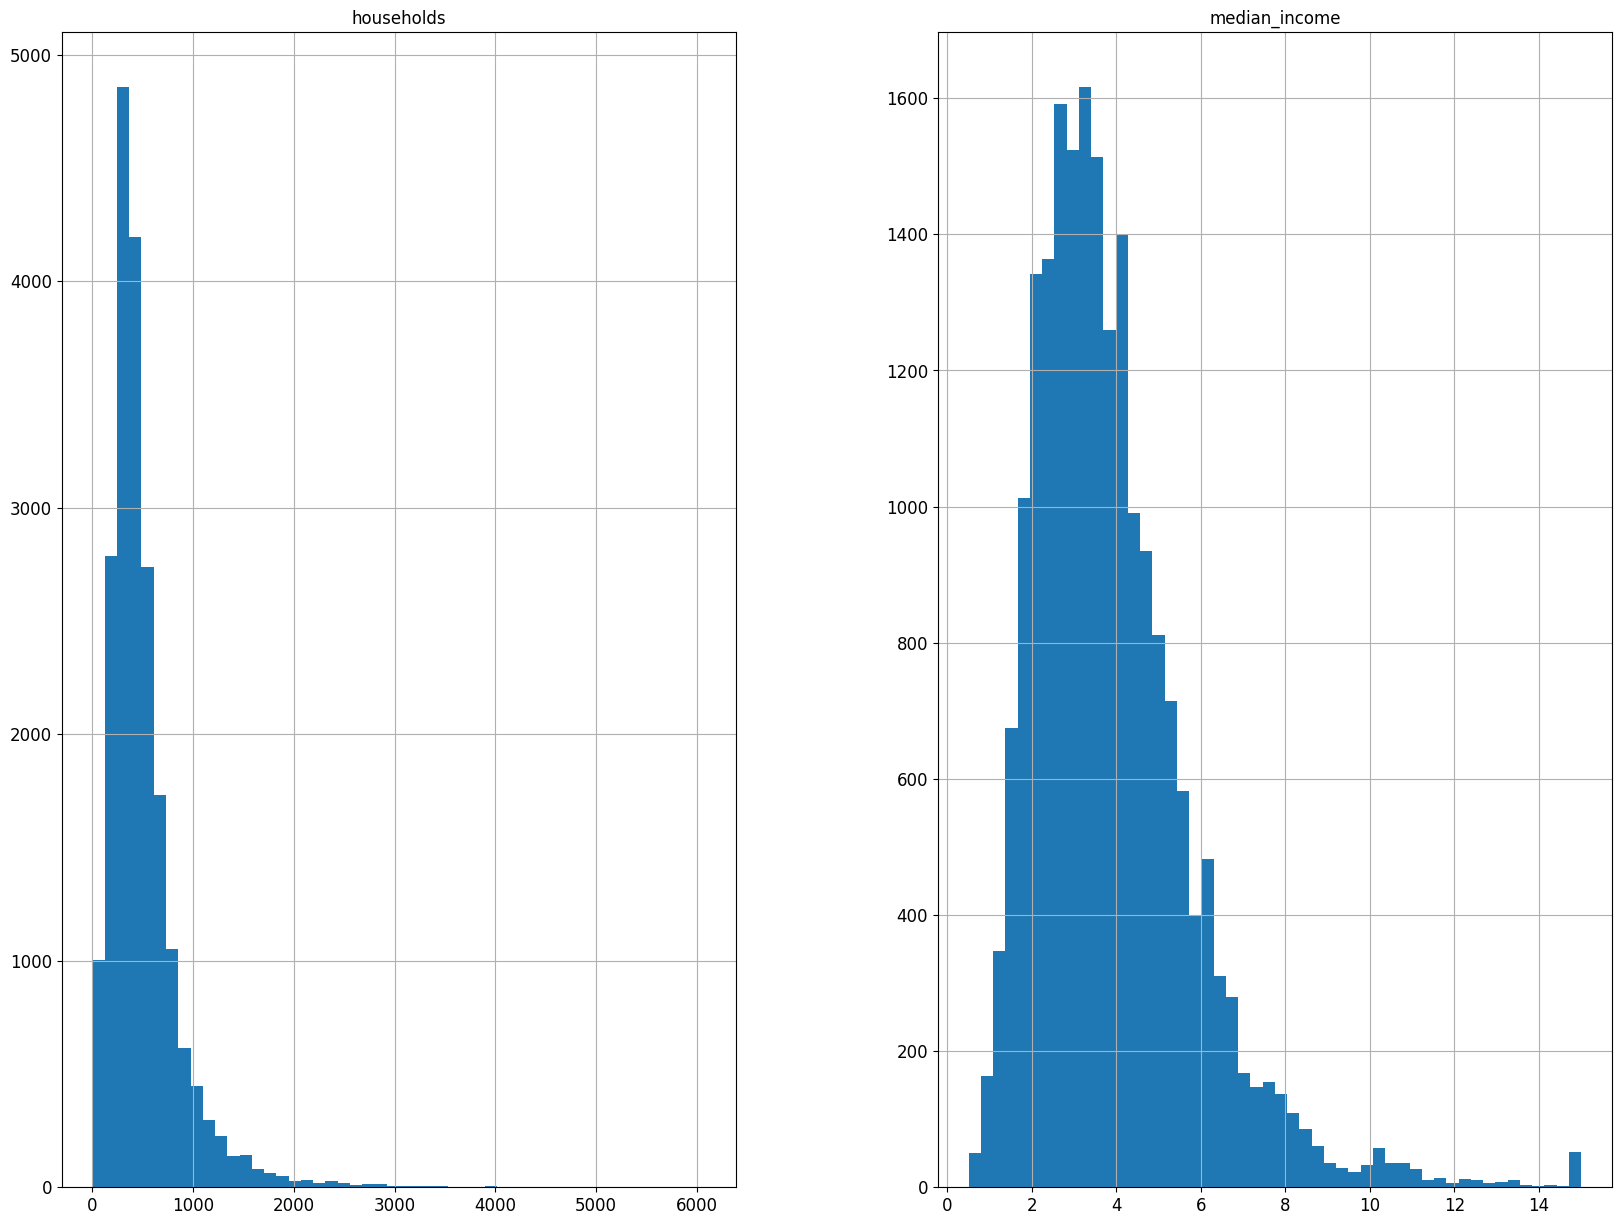

In [13]:
# To focus on two features
housing[["households","median_income"]].hist(bins=50, figsize=(20,15))

Observations:


*   median house attribue: in \$? (\$1 is equivalent to \$10,000)
*   always spend time understanding the data at hand
*   do you observe anything interesting about the median house value and housing median age? (they are capped!)
*   the features have very different scales. Is this a problem??
*   many features have distributions that are tail-heavy.
*   there are NaN values



## Visualizing Geographical Data

Let's make use of the provided longitude and latitude data to make some plots

Saving figure bad_visualization_plot


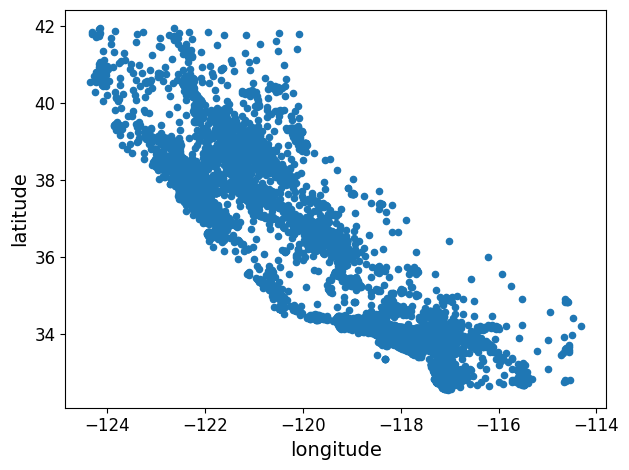

In [14]:
housing.plot(kind="scatter", x="longitude", y="latitude")
save_fig("bad_visualization_plot")

Saving figure better_visualization_plot


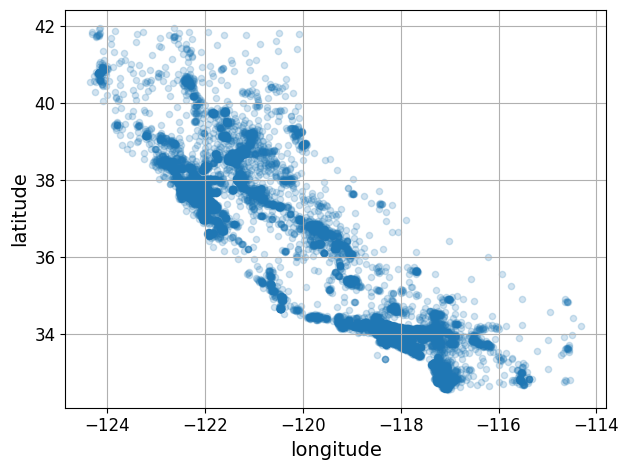

In [15]:
# try adding the alpha parameter to visualize high dense areas
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
save_fig("better_visualization_plot")
plt.show()

Saving figure housing_prices_scatterplot


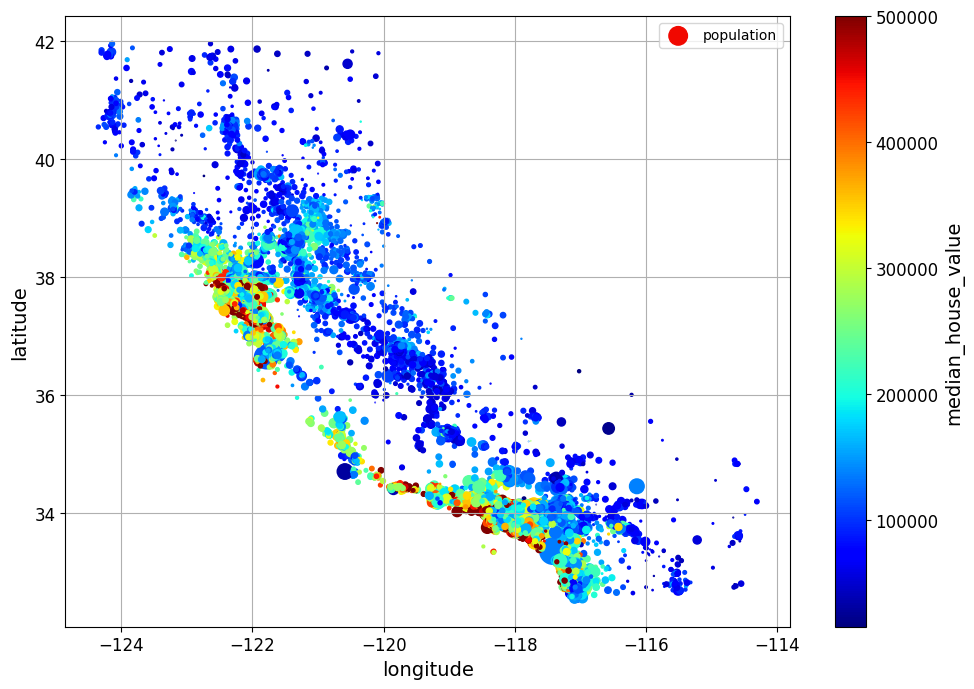

In [16]:
# let's make it even better.
# s: you can control the size of the dots based on a parameter
# c: control the color of the dots based on a parameter

housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=housing["population"] / 100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, figsize=(10, 7))
save_fig("housing_prices_scatterplot")
plt.show()



Can you conclude anything from the plot?

In [17]:
# Download the California image to plot the above images on top of it.
from pathlib import Path
import tarfile
import urllib.request

images_path = os.path.join(PROJECT_ROOT_DIR, "images", "end_to_end_project")
os.makedirs(images_path, exist_ok=True)
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
filename = "california.png"
print("Downloading", filename)
url = DOWNLOAD_ROOT + "images/end_to_end_project/" + filename
urllib.request.urlretrieve(url, os.path.join(images_path, filename))


('/content/drive/MyDrive/courses/master_AI_ML/./images/end_to_end_project/california.png',
 <http.client.HTTPMessage at 0x7d44c714c410>)

Saving figure california_housing_prices_plot


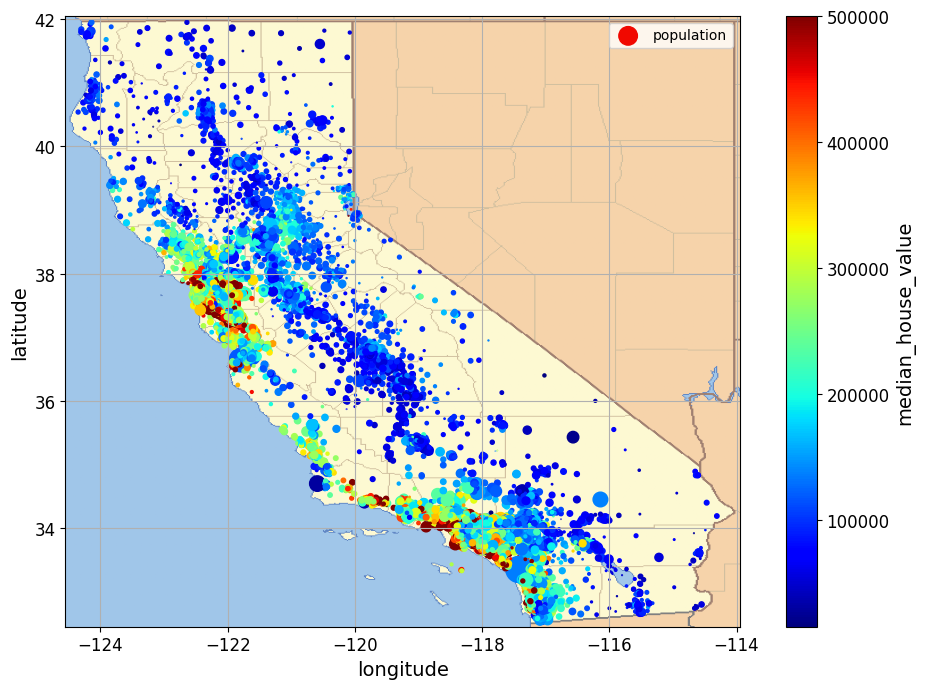

In [18]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=housing["population"] / 100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))

import matplotlib.image as mpimg
california_img=mpimg.imread(os.path.join(images_path, filename))
axis = -124.55, -113.95, 32.45, 42.05
plt.axis(axis)
plt.imshow(california_img, extent=axis)

save_fig("california_housing_prices_plot")
plt.show()

## Looking for Correlations

In [19]:
# Compute correlation matrix between numerical features (with 'numeric_only' argument)
corr_matrix = housing.corr(numeric_only = True)

In [20]:
# Show correlations with the variable we want to predict, "median_house_value"
corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688075
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population,-0.024650
longitude,-0.045967
latitude,-0.144160


Note that this shows the **linear** correlations between features. It goes between -1 and 1. What can you imply from features with correlation close to 1 and -1? And correlations close to 0?

Note: correlation of 0 does not mean that two features are not related (just not linearly)!

Saving figure scatter_matrix_plot


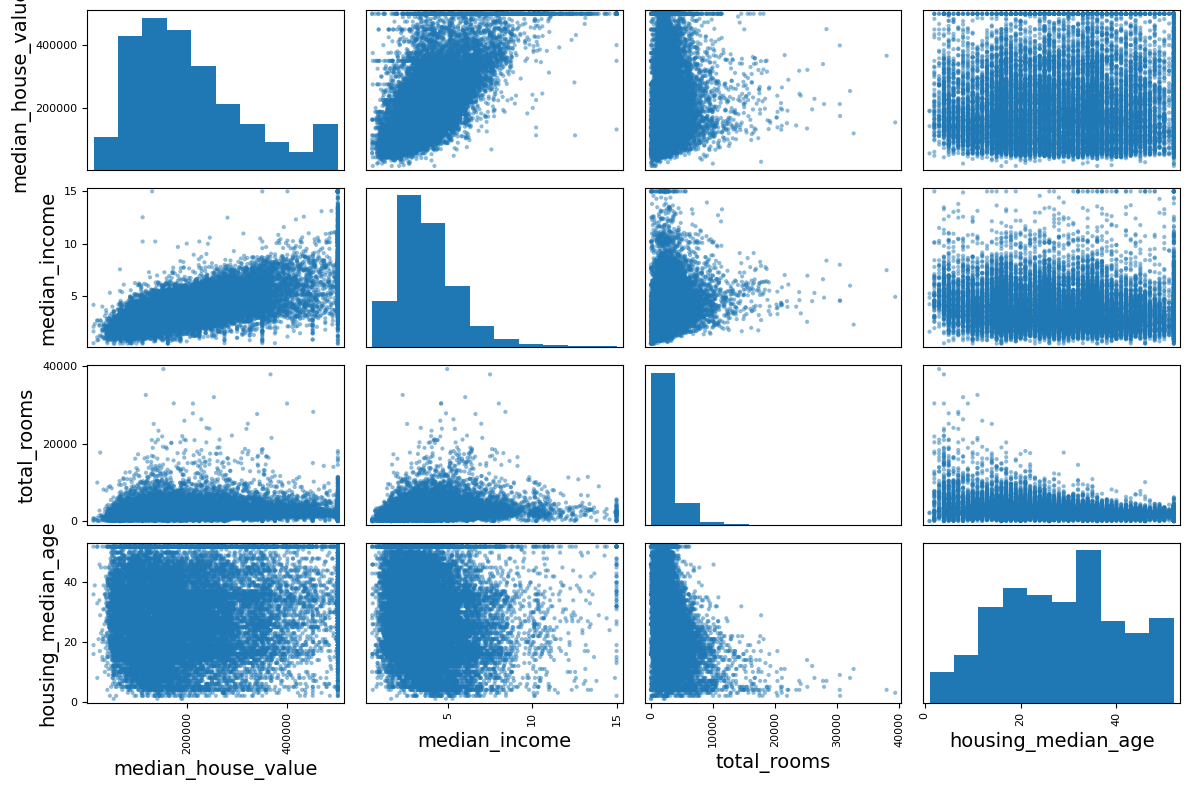

In [21]:
# for correlation, we can also use the scatter_matrix() function
# plots all with all, so we just select some of the most promising ones.
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms",
              "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
save_fig("scatter_matrix_plot")




What are the diagonal plots?

Saving figure income_vs_house_value_scatterplot


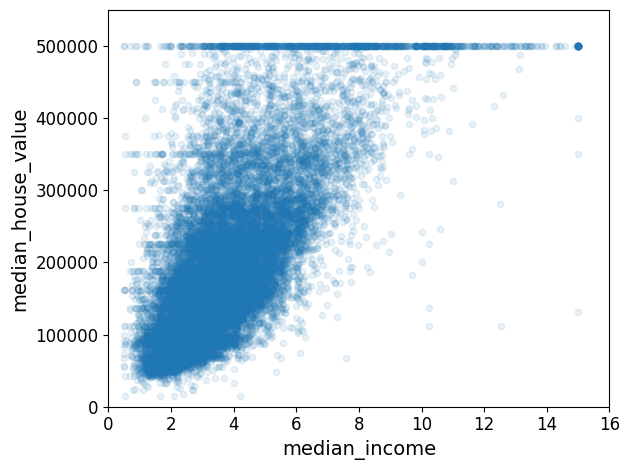

In [22]:
# Let's zoom in the median_income
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1)
plt.axis([0, 16, 0, 550000])
save_fig("income_vs_house_value_scatterplot")

## Experimenting with Attribute Combinations

We can create more attributes based on the current ones. For example, total number of rooms may not be very useful if we do not know the number of houses, same with bedrooms per room, etc.

In [23]:
housing["rooms_per_household"] = housing["total_rooms"]/housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"]/housing["total_rooms"]
housing["population_per_household"]=housing["population"]/housing["households"]

In [24]:
# let's check the correlation of the new variables
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688075
rooms_per_household,0.151948
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population_per_household,-0.023737
population,-0.024650
longitude,-0.045967


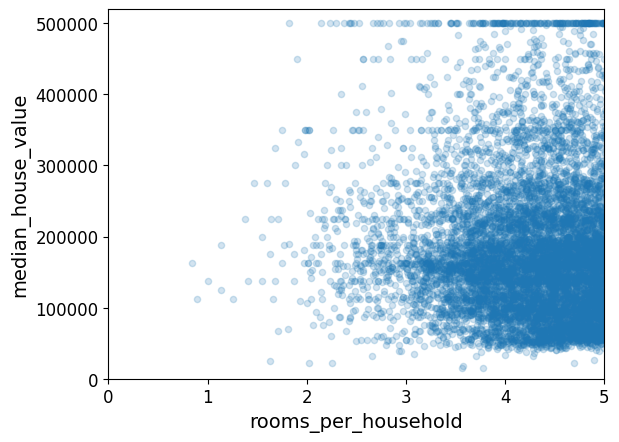

In [25]:
housing.plot(kind="scatter", x="rooms_per_household", y="median_house_value",
             alpha=0.2)
plt.axis([0, 5, 0, 520000])
plt.show()

In [26]:
# let's check the new variables
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909,5.429000,0.213039,3.070655
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874,2.474173,0.057983,10.386050
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.846154,0.100000,0.692308
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000,4.440716,0.175427,2.429741
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,5.229129,0.203162,2.818116
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000,6.052381,0.239821,3.282261
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,141.909091,1.000000,1243.333333


## Create a Test Set

In [27]:
# to make this notebook's output identical at every run
np.random.seed(42)

Note: Sadly, this won't guarantee that this notebook will output exactly the same results as in the book, since there are other possible sources of variation. The most important is the fact that algorithms get tweaked over time when libraries evolve. So please tolerate some minor differences: hopefully, most of the outputs should be the same, or at least in the right ballpark.

Note: another source of randomness is the order of Python sets: it is based on Python's `hash()` function, which is randomly "salted" when Python starts up (this started in Python 3.3, to prevent some denial-of-service attacks). To remove this randomness, the solution is to set the `PYTHONHASHSEED` environment variable to `"0"` _before_ Python even starts up. Nothing will happen if you do it after that. Luckily, if you're running this notebook on Colab, the variable is already set for you.

In [28]:
import numpy as np

# For illustration only. Sklearn has train_test_split()
def shuffle_and_split_data(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

In [29]:
train_set, test_set = shuffle_and_split_data(housing, 0.2)
print(len(train_set))
print(len(test_set))

16512
4128


EXTRA material: The problem with the implementation above is that if the dataset gets updated, the train/test split will change.
Another option is to implement a hash function to the identifier, and assign to the test to those instances that are in the lower 20\% (i.e., their value is at the bottom 20\% from the maximum value)


In [30]:
from zlib import crc32

def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32

def split_data_with_id_hash(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

# lambda:
# to apply a function to more than one column
# https://www.geeksforgeeks.org/lambda-filter-python-examples/

In [31]:
# The housing dataset does not have an index/identifier column, so we add one
housing_with_id = housing.reset_index()   # adds an `index` column
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "index")

# Note: if you add more rows in the future, they should be appended to the dataset not to modify the indexes.

In [32]:
# Another option is to use some stable features to generate the index.
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "id")

In [ ]:
test_set.head()

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household,id
59,59,-122.29,37.82,2.0,158.0,43.0,94.0,57.0,2.5625,60000.0,NEAR BAY,2.771930,0.272152,1.649123,-122252.18
60,60,-122.29,37.83,52.0,1121.0,211.0,554.0,187.0,3.3929,75700.0,NEAR BAY,5.994652,0.188225,2.962567,-122252.17
61,61,-122.29,37.82,49.0,135.0,29.0,86.0,23.0,6.1183,75000.0,NEAR BAY,5.869565,0.214815,3.739130,-122252.18
62,62,-122.29,37.81,50.0,760.0,190.0,377.0,122.0,0.9011,86100.0,NEAR BAY,6.229508,0.250000,3.090164,-122252.19
67,67,-122.29,37.80,52.0,1027.0,244.0,492.0,147.0,2.6094,81300.0,NEAR BAY,6.986395,0.237585,3.346939,-122252.20


We can also use the provided function from sklearn, which includes the random_State. The good thing is that it will split in the same way different data frames of the same length. This is useful if you have the labels as a separate dataframe.

In [33]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

In [34]:
test_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
20046,-122.38,40.67,10.0,2281.0,444.0,1274.0,438.0,2.2120,65600.0,INLAND,5.207763,0.194651,2.908676
3024,-118.37,33.83,35.0,1207.0,207.0,601.0,213.0,4.7308,353400.0,<1H OCEAN,5.666667,0.171500,2.821596
15663,-117.24,32.72,39.0,3089.0,431.0,1175.0,432.0,7.5925,466700.0,NEAR OCEAN,7.150463,0.139527,2.719907
20484,-118.44,34.05,18.0,4780.0,1192.0,1886.0,1036.0,4.4674,500001.0,<1H OCEAN,4.613900,0.249372,1.820463
9814,-118.44,34.18,33.0,2127.0,414.0,1056.0,391.0,4.3750,286100.0,<1H OCEAN,5.439898,0.194640,2.700767


So far the options assign instances to train/test "randomly".
But if there is an important feature for prediction, we could generate a significant sampling bias (same with the labels for classification problems!)


<Axes: >

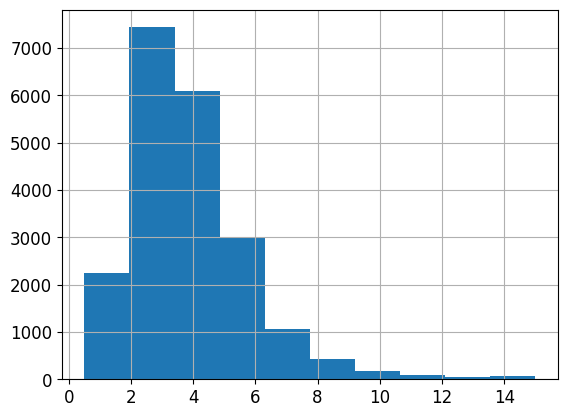

In [35]:
# Let's check the "median_income" variable
housing["median_income"].hist()

In [36]:
# Let's create some bins
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

## NOTE: This binnig idea can be useful for some variables prior to input to a ML model

In [37]:
housing["income_cat"].value_counts()

,count
income_cat,
3,7236
2,6581
4,3639
5,2362
1,822


Text(0, 0.5, 'Number of districts')

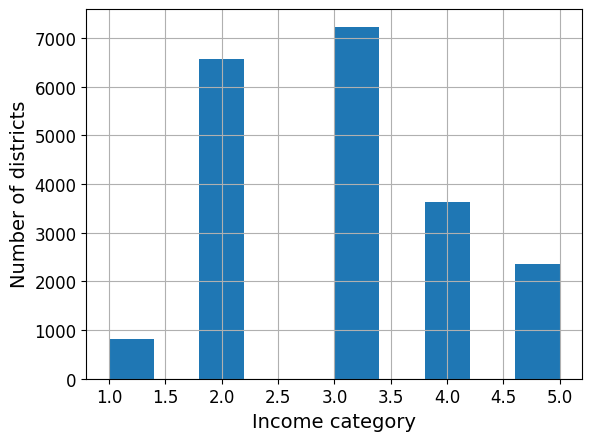

In [38]:
housing["income_cat"].hist()
plt.xlabel("Income category")
plt.ylabel("Number of districts")

In [39]:
# Now we do the split taking into account this variable, so that we get the same proportions in the train/test
strat_train_set, strat_test_set = train_test_split(
    housing, test_size=0.2, stratify=housing["income_cat"], random_state=42)

In [40]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

,count
income_cat,
3,0.350533
2,0.318798
4,0.176357
5,0.114341
1,0.039971


In [41]:
housing["income_cat"].value_counts() / len(housing)

,count
income_cat,
3,0.350581
2,0.318847
4,0.176308
5,0.114438
1,0.039826


In [42]:
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(housing),
    "Stratified": income_cat_proportions(strat_test_set),
    "Random": income_cat_proportions(test_set),
}).sort_index()
compare_props["Rand. %error"] = 100 * compare_props["Random"] / compare_props["Overall"] - 100
compare_props["Strat. %error"] = 100 * compare_props["Stratified"] / compare_props["Overall"] - 100

In [43]:
compare_props

,Overall,Stratified,Random,Rand. %error,Strat. %error
income_cat,,,,,
1,0.039826,0.039971,0.042393,6.447689,0.364964
2,0.318847,0.318798,0.307413,-3.586081,-0.015195
3,0.350581,0.350533,0.345203,-1.533997,-0.013820
4,0.176308,0.176357,0.184109,4.424292,0.027480
5,0.114438,0.114341,0.120882,5.630821,-0.084674


In [44]:
# we can now drop this variable we created just to do the split.
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

# Prepare the Data for Machine Learning Algorithms

Split data into X (features) and y (label)

In [45]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

## Data Cleaning

The total_bedrooms attribute has some missing values. Most ML methods can not work with missing values, so we need to take care of them.

Note that we are always working with the TRAIN SET, since the TEST SET should always be left apart.

We explore 3 options to handle NaN values:

```python
housing.dropna(subset=["total_bedrooms"], inplace=True)    # option 1

housing.drop("total_bedrooms", axis=1)       # option 2

median = housing["total_bedrooms"].median()  # option 3
housing["total_bedrooms"].fillna(median, inplace=True)
```

For each option, we'll create a copy of `housing` and work on that copy to avoid breaking `housing`. We'll also show the output of each option, but filtering on the rows that originally contained a NaN value to easier visualize what each option does.

In [48]:
# Extract the first 5 rows with NaN values
sample_incomplete_rows = housing[housing.isnull().any(axis=1)].head()
sample_incomplete_rows

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
14452,-120.67,40.50,15.0,5343.0,NaN,2503.0,902.0,3.5962,INLAND,5.923503,NaN,2.774945
18217,-117.96,34.03,35.0,2093.0,NaN,1755.0,403.0,3.4115,<1H OCEAN,5.193548,NaN,4.354839
11889,-118.05,34.04,33.0,1348.0,NaN,1098.0,257.0,4.2917,<1H OCEAN,5.245136,NaN,4.272374
20325,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,<1H OCEAN,6.367713,NaN,2.542601
14360,-117.87,33.62,8.0,1266.0,NaN,375.0,183.0,9.8020,<1H OCEAN,6.918033,NaN,2.049180


OPTION 1

In [49]:
sample_incomplete_rows.dropna(subset=["total_bedrooms"])    # option 1

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household


Q: What is Option 1 doing?




OPTION 2

In [50]:
sample_incomplete_rows.drop("total_bedrooms", axis=1)       # option 2

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
14452,-120.67,40.50,15.0,5343.0,2503.0,902.0,3.5962,INLAND,5.923503,NaN,2.774945
18217,-117.96,34.03,35.0,2093.0,1755.0,403.0,3.4115,<1H OCEAN,5.193548,NaN,4.354839
11889,-118.05,34.04,33.0,1348.0,1098.0,257.0,4.2917,<1H OCEAN,5.245136,NaN,4.272374
20325,-118.88,34.17,15.0,4260.0,1701.0,669.0,5.1033,<1H OCEAN,6.367713,NaN,2.542601
14360,-117.87,33.62,8.0,1266.0,375.0,183.0,9.8020,<1H OCEAN,6.918033,NaN,2.049180


Q: What is Option 2 doing?


OPTION 3: Imputation

In [51]:
median = housing["total_bedrooms"].median()
sample_incomplete_rows["total_bedrooms"] = sample_incomplete_rows["total_bedrooms"].fillna(median) # option 3

In [52]:
sample_incomplete_rows

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
14452,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962,INLAND,5.923503,NaN,2.774945
18217,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115,<1H OCEAN,5.193548,NaN,4.354839
11889,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917,<1H OCEAN,5.245136,NaN,4.272374
20325,-118.88,34.17,15.0,4260.0,434.0,1701.0,669.0,5.1033,<1H OCEAN,6.367713,NaN,2.542601
14360,-117.87,33.62,8.0,1266.0,434.0,375.0,183.0,9.8020,<1H OCEAN,6.918033,NaN,2.049180


Q: What is Option 3 doing?


In [53]:
# For implementing option 3, there are already methods in sklearn, like SimpleImputer
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

Separating out the numerical attributes to use the `"median"` strategy (as it cannot be calculated on text attributes like `ocean_proximity`):

In [54]:
housing_num = housing.drop("ocean_proximity", axis=1)
# alternatively: housing_num = housing.select_dtypes(include=[np.number])

In [55]:
# This will compute the median for each attribute (only numerical)
# We FIT() first
imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [56]:
# let's plot the medians
imputer.statistics_

array([-1.18510000e+02,  3.42600000e+01,  2.90000000e+01,  2.12500000e+03,
        4.34000000e+02,  1.16700000e+03,  4.08000000e+02,  3.53850000e+00,
        5.23557310e+00,  2.03105786e-01,  2.82231619e+00])

Check that this is the same as manually computing the median of each attribute:

In [57]:
housing_num.median().values

array([-1.18510000e+02,  3.42600000e+01,  2.90000000e+01,  2.12500000e+03,
        4.34000000e+02,  1.16700000e+03,  4.08000000e+02,  3.53850000e+00,
        5.23557310e+00,  2.03105786e-01,  2.82231619e+00])

Transform the training set:

In [58]:
# Substitute null values with the correponding median values previosly computed
# We do TRANSFORM() now
X = imputer.transform(housing_num)

In [59]:
X

array([[-122.42      ,   37.8       ,   52.        , ...,    3.21179884,
           0.33574225,    1.52417795],
       [-118.38      ,   34.14      ,   40.        , ...,    5.50420168,
           0.18015267,    1.86554622],
       [-121.98      ,   38.36      ,   33.        , ...,    5.33497537,
           0.20036934,    2.76847291],
       ...,
       [-117.06      ,   32.59      ,   13.        , ...,    5.15789474,
           0.19770408,    3.70263158],
       [-118.4       ,   34.06      ,   37.        , ...,    4.51193317,
           0.2308913 ,    2.05847255],
       [-122.41      ,   37.66      ,   44.        , ...,    2.03301887,
           0.45243619,    3.21698113]])

In [60]:
# X is a plain NumPy array, so we can convert it back to a Pandas dataframe
# Note that we mantain the column names and the original index
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing.index)

In [61]:
housing_tr.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,bedrooms_per_room,population_per_household
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,3.211799,0.335742,1.524178
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,5.504202,0.180153,1.865546
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,5.334975,0.200369,2.768473
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,5.351282,0.203881,2.365385
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,3.725256,0.277371,1.631399


In [62]:
# let's check the imputed values for those instances that we know where null before
housing_tr.loc[sample_incomplete_rows.index.values]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,bedrooms_per_room,population_per_household
14452,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962,5.923503,0.203106,2.774945
18217,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115,5.193548,0.203106,4.354839
11889,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917,5.245136,0.203106,4.272374
20325,-118.88,34.17,15.0,4260.0,434.0,1701.0,669.0,5.1033,6.367713,0.203106,2.542601
14360,-117.87,33.62,8.0,1266.0,434.0,375.0,183.0,9.8020,6.918033,0.203106,2.049180


In [63]:
imputer.strategy

'median'

**IMPORTANT:** When transforming the TEST SET, if we used some statistics for the transformations, like the median of the numerical features, those are directly applied to the test set, i.e., the statistics do not have to be computed on the test set!!

In Python language, this means that on the TEST SET you will use the .TRANSFORM(), but NOT the .FIT().

## Handling Text and Categorical Attributes



Now let's preprocess the categorical input feature, `ocean_proximity`:

In [64]:
# Let's lookk only at the categorical variables
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(10)


,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY
18031,<1H OCEAN
6753,<1H OCEAN


In [65]:
housing_cat["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,7274
INLAND,5301
NEAR OCEAN,2089
NEAR BAY,1846
ISLAND,2


OPTION 1: ORDINAL ENCODER

In [66]:
# We now perform a label encoding
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder() # Initialize it, object "ordinal_encoder"
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)


In [67]:
housing_cat_encoded[:10]

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.],
       [0.],
       [0.]])

In [68]:
# We can check the category for each number so that we can do a one-to-one mapping
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [69]:
housing_cat.head()

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN


In [70]:
np.unique(housing_cat_encoded)

array([0., 1., 2., 3., 4.])

Option 2: One-Hot Encoding (more typical for the label)

In [71]:
# Another option is to do one-hot encoding
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

By default, the `OneHotEncoder` class returns a sparse array, but we can convert it to a dense array if needed by calling the `toarray()` method:

In [72]:
housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

Alternatively, you can set `sparse=False` when creating the `OneHotEncoder`:

In [73]:
# Here as well we can check the different categories and their order in the new created one-hot vectors
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

**Note:** careful if using pandas' function .get_dummies()
It converts each categorical feature into a one-hot representation, with one binary feature per category.

But it does not remember the categories, this can lead to ERRORS!!

Not recommended

In [74]:
df_test_unknown = pd.DataFrame({"ocean_proximity": ["<2H OCEAN", "ISLAND"]})
pd.get_dummies(df_test_unknown)

,ocean_proximity_<2H OCEAN,ocean_proximity_ISLAND
0,True,False
1,False,True


Although it looks simple, get_dummies() does not remember the categories!!! So better use OneHotEncoding


In [76]:
# cat_encoder.transform(df_test_unknown)

# Gives the following error: Found unknown categories ['<2H OCEAN'] in column 0 during trans

NOTE: As with the numerical variables, here we will do the same transformation to the TEST SET, using only the .TRANSFORM().

## Feature Scaling

Generally speaking, machine learning models do not perform well when the input numerical features have very different scales.

Typical transformations: min-max scaler and standardization

In [77]:
from sklearn.preprocessing import MinMaxScaler

# with features_range you can modify the range (by default 0-1)
min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>,
        <Axes: title={'center': '2'}>],
       [<Axes: title={'center': '3'}>, <Axes: title={'center': '4'}>,
        <Axes: title={'center': '5'}>],
       [<Axes: title={'center': '6'}>, <Axes: title={'center': '7'}>,
        <Axes: title={'center': '8'}>],
       [<Axes: title={'center': '9'}>, <Axes: title={'center': '10'}>,
        <Axes: >]], dtype=object)

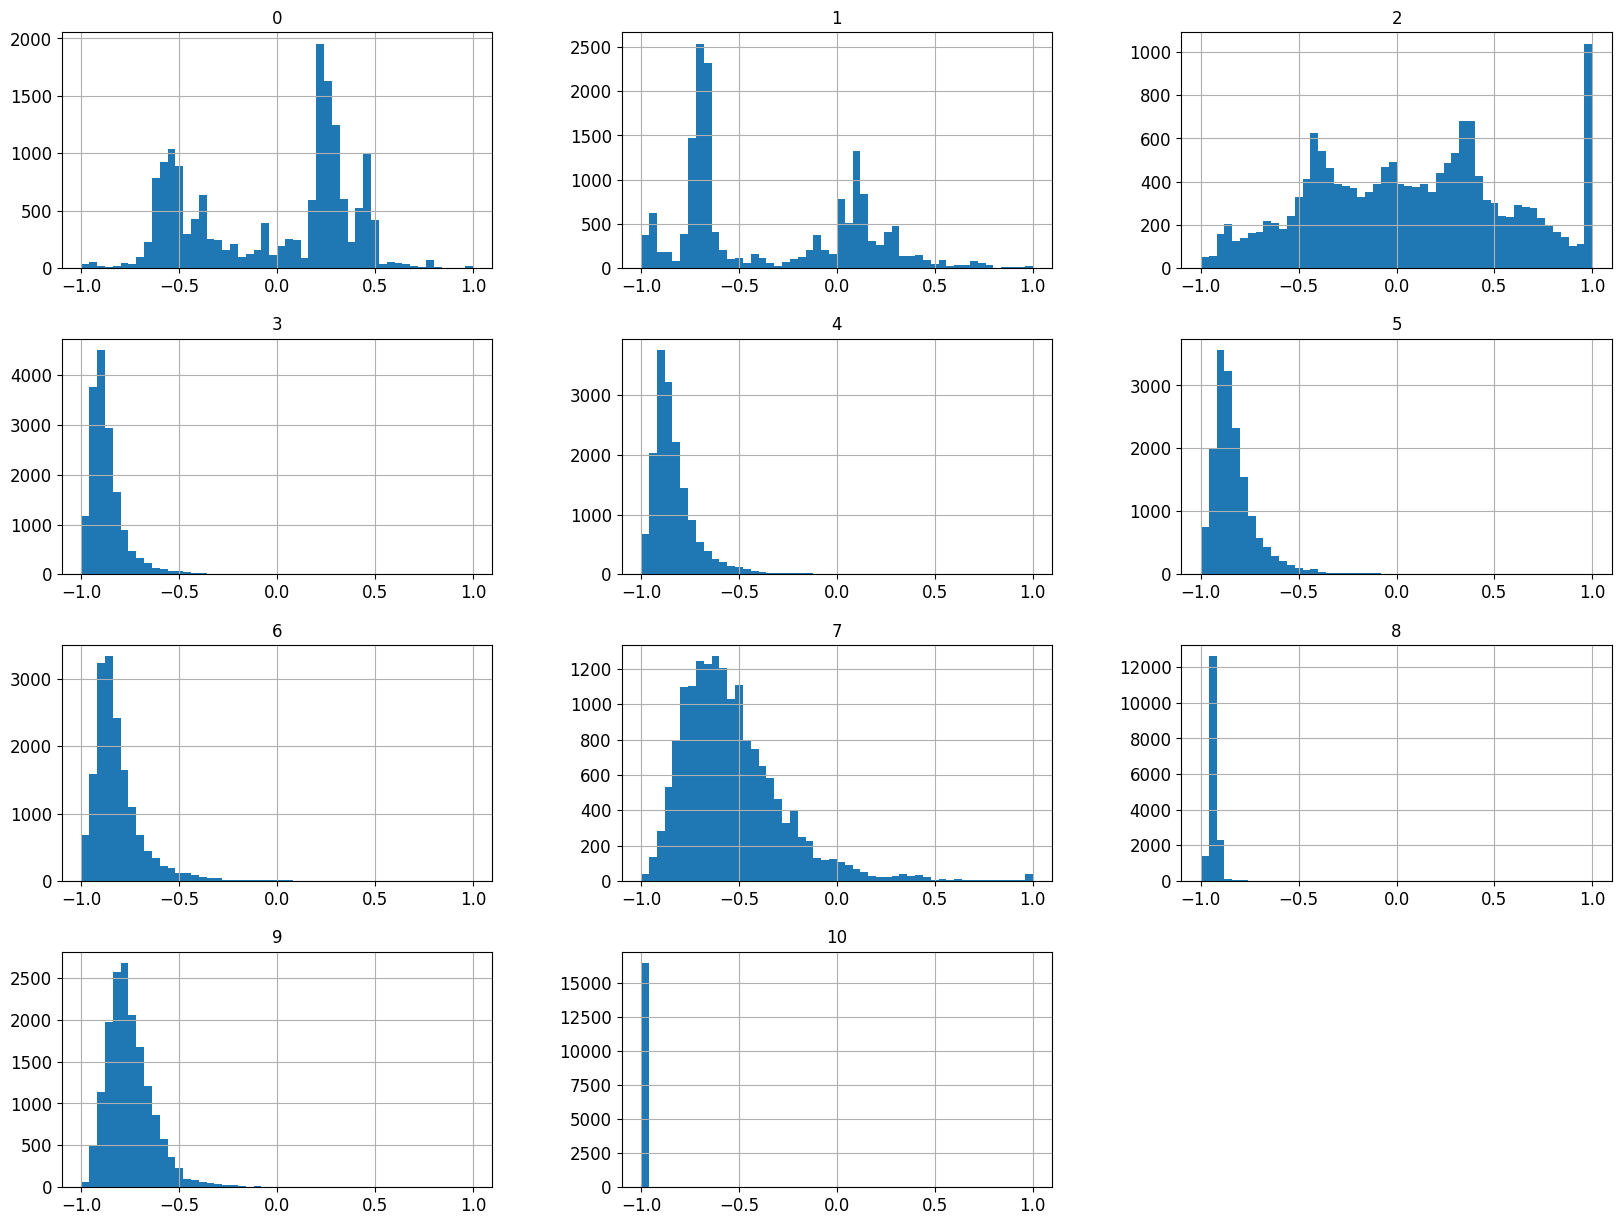

In [78]:
tmp_min_max = pd.DataFrame(housing_num_min_max_scaled)
tmp_min_max.hist(bins=50, figsize=(20,15))

In [79]:
from sklearn.preprocessing import StandardScaler
# Converts the data into normal(0,1).
# Less affected by outliers.
std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>,
        <Axes: title={'center': '2'}>],
       [<Axes: title={'center': '3'}>, <Axes: title={'center': '4'}>,
        <Axes: title={'center': '5'}>],
       [<Axes: title={'center': '6'}>, <Axes: title={'center': '7'}>,
        <Axes: title={'center': '8'}>],
       [<Axes: title={'center': '9'}>, <Axes: title={'center': '10'}>,
        <Axes: >]], dtype=object)

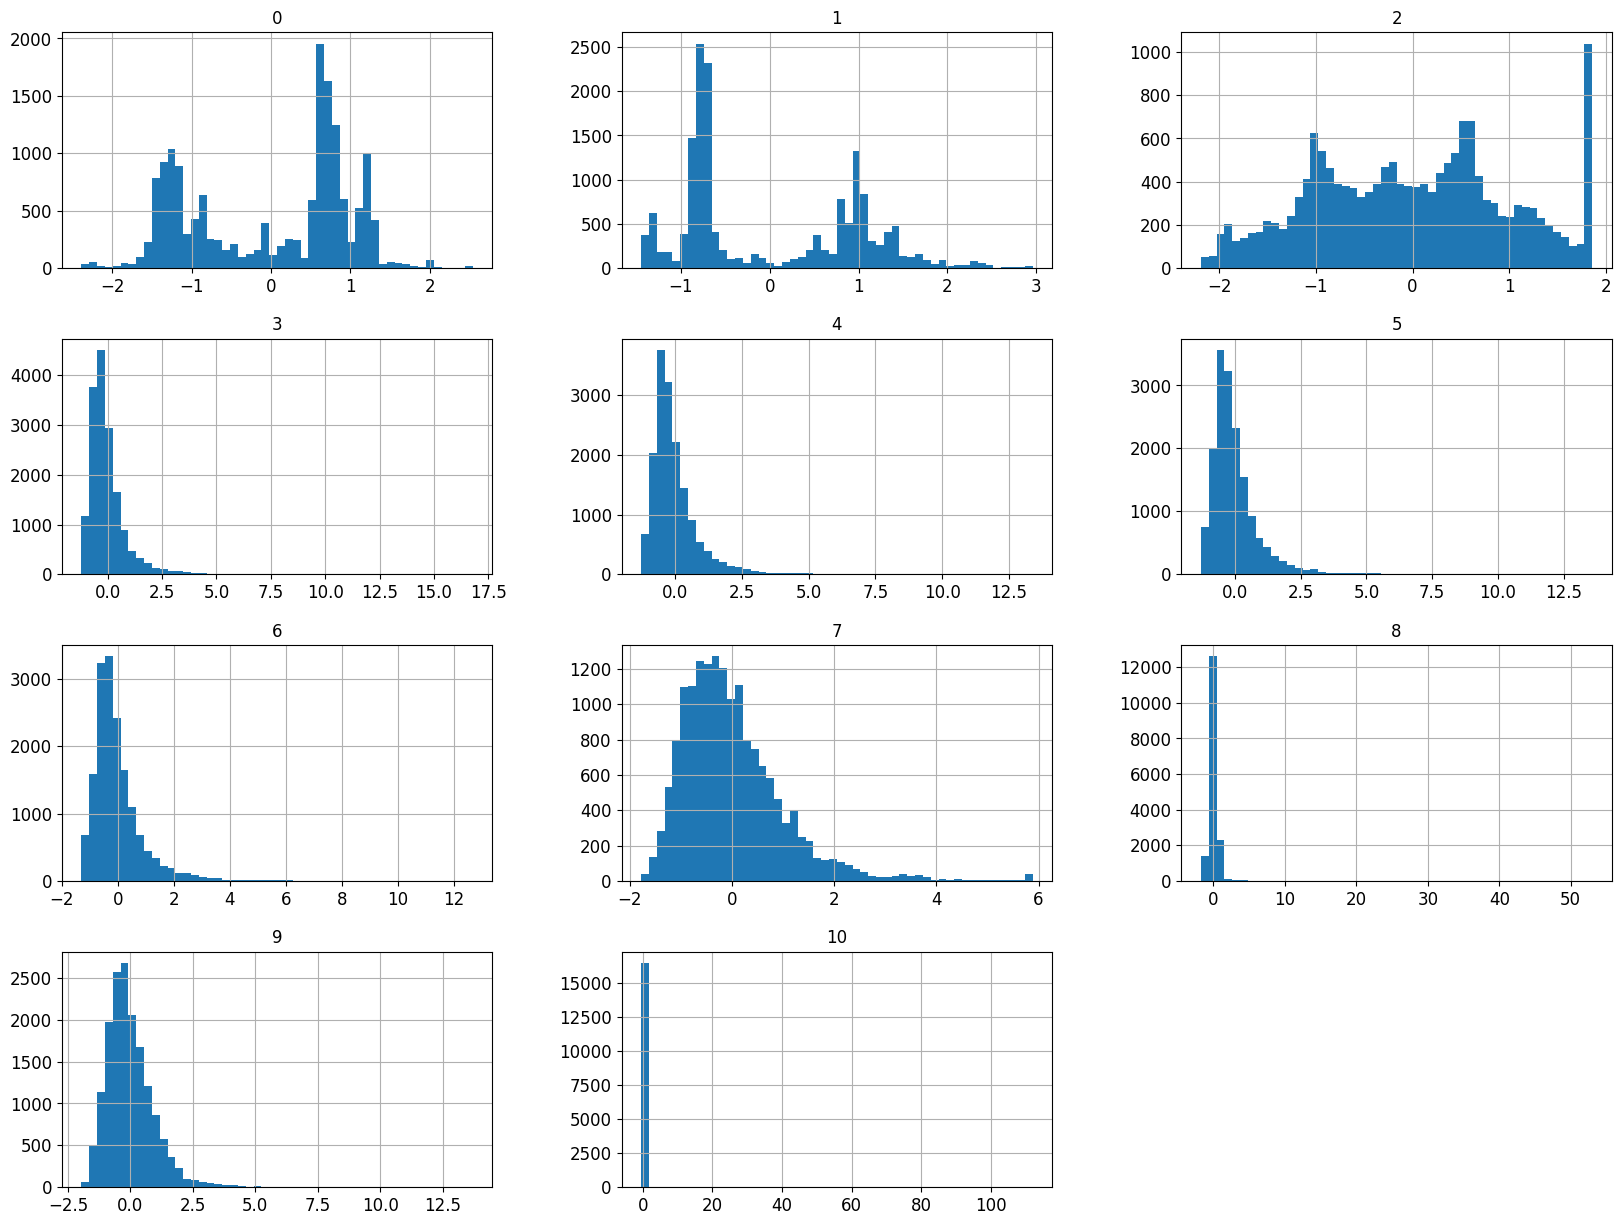

In [80]:
tmp_std_scaled = pd.DataFrame(housing_num_std_scaled)
tmp_std_scaled.hist(bins=50, figsize=(20,15))

Saving figure long_tail_plot


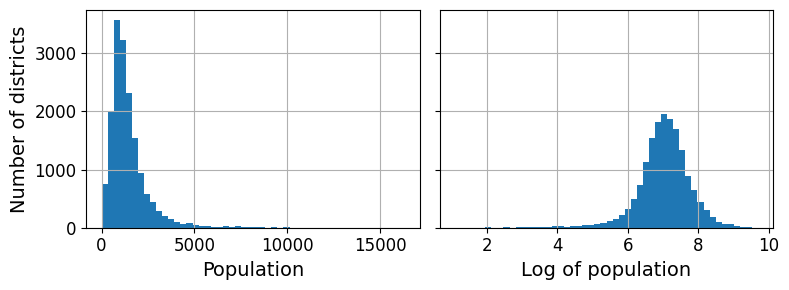

In [81]:
# If a feature has a heavy tail, it may be best to transform it differently
# min-max and standardization will convert most values into very small range
# better to shrink first the heavy tail, and make the distr. more symmetrical

# some transformations: sqrt(), log(), pow(x) [x between 0 and 1]

fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing["population"].hist(ax=axs[0], bins=50)
housing["population"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")
save_fig("long_tail_plot")
plt.show()

EXTRA MATERIAL: We could also apply a transformation to the labels (e.g., log). However, if we do this, the predictor will now predict log(price) instead of price.

You can then use .inverse_transform of the predictions to revert them to their original scale (meaning).

In [82]:
# Example: apply LR to median_income to predict scaled labels.
from sklearn.linear_model import LinearRegression

target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(housing_labels.to_frame())

In [83]:
model = LinearRegression()
model.fit(housing[["median_income"]], scaled_labels)
some_new_data = housing[["median_income"]].iloc[:5]  # pretend this is new data

scaled_predictions = model.predict(some_new_data)
predictions = target_scaler.inverse_transform(scaled_predictions)

In [84]:
predictions

array([[131997.15275877],
       [299359.35844434],
       [146023.37185694],
       [138840.33653057],
       [192016.61557639]])

In [85]:
# We could have done this automatically with the "TransformedTargetRegressor"

from sklearn.compose import TransformedTargetRegressor

# Specify the model and the label transform
model = TransformedTargetRegressor(LinearRegression(),
                                   transformer=StandardScaler())
model.fit(housing[["median_income"]], housing_labels)
predictions = model.predict(some_new_data)

In [86]:
predictions

array([131997.15275877, 299359.35844434, 146023.37185694, 138840.33653057,
       192016.61557639])

## Extra Material: Custom Transformers

Let's create a custom transformer to perform StandardScaling

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
# TransformerMixin: to get fit_transform()
# BaseEstimator: avoid using input arguments

from sklearn.utils.validation import check_array, check_is_fitted
# Contains several functions to validate the inputs

class StandardScalerClone(BaseEstimator, TransformerMixin):
    def __init__(self, with_mean=True):  # no *args or **kwargs!
        self.with_mean = with_mean

    def fit(self, X, y=None):  # y is required even though we don't use it
        X = check_array(X)  # checks that X is an array with finite float values
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0)
        self.n_features_in_ = X.shape[1]  # every estimator stores this in fit(). Ensures all data passed to transform() or predict() has this number of features
        return self  # fit() always return self!

    def transform(self, X):
        check_is_fitted(self)  # looks for learned attributes (with trailing _)
        X = check_array(X)
        assert self.n_features_in_ == X.shape[1]
        if self.with_mean:
            X = X - self.mean_
        return X / self.scale_

In [ ]:
scale_custom = StandardScalerClone()
housing_num_std_scaled_custom = scale_custom.fit_transform(housing_tr)


In [ ]:
housing_num_std_scaled_custom

array([[-1.42303652,  1.0136059 ,  1.86111875, ..., -0.86602737,
         2.15374302, -0.33020372],
       [ 0.59639445, -0.702103  ,  0.90762971, ...,  0.0245495 ,
        -0.56965098, -0.25361631],
       [-1.2030985 ,  1.27611874,  0.35142777, ..., -0.04119332,
        -0.21578431, -0.05104091],
       ...,
       [ 1.25620853, -1.42870103, -1.23772062, ..., -0.10998748,
        -0.26243628,  0.15854151],
       [ 0.58639727, -0.73960483,  0.66925745, ..., -0.36093745,
         0.31846297, -0.21033248],
       [-1.41803793,  0.94797769,  1.22545939, ..., -1.32397227,
         4.19631947,  0.04958379]])

In [ ]:
housing_num_std_scaled

array([[-1.42303652,  1.0136059 ,  1.86111875, ..., -0.86602737,
         2.14135179, -0.33020372],
       [ 0.59639445, -0.702103  ,  0.90762971, ...,  0.0245495 ,
        -0.56854491, -0.25361631],
       [-1.2030985 ,  1.27611874,  0.35142777, ..., -0.04119332,
        -0.21643202, -0.05104091],
       ...,
       [ 1.25620853, -1.42870103, -1.23772062, ..., -0.10998748,
        -0.26285278,  0.15854151],
       [ 0.58639727, -0.73960483,  0.66925745, ..., -0.36093745,
         0.3151675 , -0.21033248],
       [-1.41803793,  0.94797769,  1.22545939, ..., -1.32397227,
         4.1738051 ,  0.04958379]])

Also, `housing_num_std_scaled_custom` is a NumPy array, we've lost the column names (unfortunately, that's a problem with Scikit-Learn). To recover a `DataFrame`, you could run this:

In [ ]:
housing_tr_scaled_custom = pd.DataFrame(
    housing_num_std_scaled_custom,
    columns=list(housing_tr.columns),
    index=housing_tr.index)
housing_tr_scaled_custom.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,bedrooms_per_room,population_per_household
13096,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491,-0.866027,2.153743,-0.330204
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942,0.024550,-0.569651,-0.253616
3785,-1.203098,1.276119,0.351428,-0.712240,-0.760709,-0.788768,-0.775727,-0.759789,-0.041193,-0.215784,-0.051041
14689,1.231216,-0.884924,-0.919891,0.702262,0.742306,0.383175,0.731375,-0.850281,-0.034858,-0.154314,-0.141475
20507,0.711362,-0.875549,0.589800,0.790125,1.595753,0.444376,1.755263,-0.180365,-0.666554,1.132023,-0.306148


## Transformation Pipelines

Now let's build a pipeline for preprocessing the numerical attributes.

In [87]:
# Pipeline for the numerical features
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        ('std_scaler', StandardScaler()),
    ])

housing_num_tr = num_pipeline.fit_transform(housing_num)

In [88]:
# Another option
from sklearn.pipeline import make_pipeline
num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

In [89]:
housing_num_tr = num_pipeline.fit_transform(housing_num)
housing_num_tr

array([[-1.42303652,  1.0136059 ,  1.86111875, ..., -0.86602737,
         2.15374302, -0.33020372],
       [ 0.59639445, -0.702103  ,  0.90762971, ...,  0.0245495 ,
        -0.56965098, -0.25361631],
       [-1.2030985 ,  1.27611874,  0.35142777, ..., -0.04119332,
        -0.21578431, -0.05104091],
       ...,
       [ 1.25620853, -1.42870103, -1.23772062, ..., -0.10998748,
        -0.26243628,  0.15854151],
       [ 0.58639727, -0.73960483,  0.66925745, ..., -0.36093745,
         0.31846297, -0.21033248],
       [-1.41803793,  0.94797769,  1.22545939, ..., -1.32397227,
         4.19631947,  0.04958379]])

In [90]:
# Transformers have the method get_feature_names_out() that stores the column names
df_housing_num_prepared = pd.DataFrame(
    housing_num_tr, columns=num_pipeline.get_feature_names_out(),
    index=housing_num.index)

In [91]:
df_housing_num_prepared

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,bedrooms_per_room,population_per_household
13096,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491,-0.866027,2.153743,-0.330204
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942,0.024550,-0.569651,-0.253616
3785,-1.203098,1.276119,0.351428,-0.712240,-0.760709,-0.788768,-0.775727,-0.759789,-0.041193,-0.215784,-0.051041
14689,1.231216,-0.884924,-0.919891,0.702262,0.742306,0.383175,0.731375,-0.850281,-0.034858,-0.154314,-0.141475
20507,0.711362,-0.875549,0.589800,0.790125,1.595753,0.444376,1.755263,-0.180365,-0.666554,1.132023,-0.306148
...,...,...,...,...,...,...,...,...,...,...,...
14207,0.586397,-0.833359,0.987087,-0.184147,0.140152,-0.445315,0.060101,0.444041,-0.452111,0.948316,-0.269780
13105,0.131525,0.319822,-0.443146,0.139847,0.128298,-0.005950,0.083608,-0.685630,0.036792,-0.204419,-0.073741
19301,1.256209,-1.428701,-1.237721,0.586026,0.562134,1.268299,0.679135,0.101049,-0.109987,-0.262436,0.158542
19121,0.586397,-0.739605,0.669257,0.522417,0.794461,0.273563,0.882868,0.145396,-0.360937,0.318463,-0.210332


In [92]:
# Let's do a single pipeline that also takes care of the categorical features using the ColumnTransformer
from sklearn.compose import ColumnTransformer

# num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
#               "total_bedrooms", "population", "households", "median_income"]
num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"))

# ColumnTransformer: 3-tuples (name, transformer, list of names or indices of columns to apply the transformer)
preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

In [93]:
housing_prepared = preprocessing.fit_transform(housing)

In [94]:
housing_prepared

array([[-1.42303652,  1.0136059 ,  1.86111875, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.59639445, -0.702103  ,  0.90762971, ...,  0.        ,
         0.        ,  0.        ],
       [-1.2030985 ,  1.27611874,  0.35142777, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 1.25620853, -1.42870103, -1.23772062, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.58639727, -0.73960483,  0.66925745, ...,  0.        ,
         0.        ,  0.        ],
       [-1.41803793,  0.94797769,  1.22545939, ...,  0.        ,
         0.        ,  1.        ]])

In [95]:
housing_prepared.shape

(16512, 16)

In [96]:
preprocessing.get_feature_names_out()

array(['num__longitude', 'num__latitude', 'num__housing_median_age',
       'num__total_rooms', 'num__total_bedrooms', 'num__population',
       'num__households', 'num__median_income',
       'num__rooms_per_household', 'num__bedrooms_per_room',
       'num__population_per_household', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN'],
      dtype=object)

# Select and Train a Model

## Training and Evaluating on the Training Set

In [97]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

LinearRegression()

In [98]:
# let's try the full preprocessing pipeline on a few training instances
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]
some_data_prepared = preprocessing.transform(some_data)

print("Predictions:", lin_reg.predict(some_data_prepared))

Predictions: [281846.75707821 333295.31388159 116953.76804522 104884.36771394
 309134.97562826]


Compare against the actual values:

In [99]:
print("Labels:", list(some_labels))

Labels: [458300.0, 483800.0, 101700.0, 96100.0, 361800.0]


In [100]:
# let's compute the MSE and RMSE on the Training set
from sklearn.metrics import mean_squared_error

housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

# The average error is around $68000!!
# this means that either the models is underfitting (not complex enough), or the features do not contain
# enough info to make predictions

np.float64(67269.98114035041)

In [101]:
# Compute RMSE directly
from sklearn.metrics import root_mean_squared_error

lin_rmse2 = root_mean_squared_error(housing_labels, housing_predictions)
lin_rmse2

67269.98114035041

In [102]:
# MAE
from sklearn.metrics import mean_absolute_error

lin_mae = mean_absolute_error(housing_labels, housing_predictions)
lin_mae

48791.52179289652

In [103]:
# We could try a more complex model, a TREE
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(housing_prepared, housing_labels)

DecisionTreeRegressor(random_state=42)

In [104]:
housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse

# Does this mean that the model is perfect??

np.float64(0.0)

## Better Evaluation Using Cross-Validation

In [105]:
# Let's do CV on the TREE model and average the results
# Note: the CV function expects an utility function to maximize (the larger the better),
# reason to use neg_mean_squared_error
from sklearn.model_selection import cross_val_score

scores = cross_val_score(tree_reg, housing_prepared, housing_labels,
                         scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)

In [106]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(tree_rmse_scores)

Scores: [69035.50316425 66440.32489444 67557.90097875 71163.42519558
 69144.71851684 71789.84980983 70507.09898267 73433.47483902
 68938.79789986 69692.31655092]
Mean: 69770.3410832157
Standard deviation: 1938.899204338071


In [107]:
lin_scores = cross_val_score(lin_reg, housing_prepared, housing_labels,
                             scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

Scores: [68880.34546807 66064.16097839 65695.02939809 68284.78318352
 66289.22280614 68513.77150023 66687.79577218 69388.33071876
 66669.88720917 67516.12228663]
Mean: 67398.94493211733
Standard deviation: 1230.7395911089582


LR actually performs better than the TREE model! It was overfitting.

In [108]:
# Let's try now a RF
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
forest_reg.fit(housing_prepared, housing_labels)

RandomForestRegressor(random_state=42)

In [109]:
housing_predictions = forest_reg.predict(housing_prepared)
forest_mse = mean_squared_error(housing_labels, housing_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_rmse

np.float64(18496.958508268486)

In [ ]:
from sklearn.model_selection import cross_val_score

forest_scores = cross_val_score(forest_reg, housing_prepared, housing_labels,
                                scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

In [ ]:
scores = cross_val_score(lin_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10)
pd.Series(np.sqrt(-scores)).describe()

,0
count,10.000000
mean,67398.944932
std,1297.313438
min,65695.029398
25%,66384.388907
50%,67101.959029
75%,68456.524421
max,69388.330719


In [ ]:
from sklearn.svm import SVR

svm_reg = SVR(kernel="linear")
svm_reg.fit(housing_prepared, housing_labels)
housing_predictions = svm_reg.predict(housing_prepared)
svm_mse = mean_squared_error(housing_labels, housing_predictions)
svm_rmse = np.sqrt(svm_mse)
svm_rmse

110461.11477506068

# Fine-Tune Your Model

## Grid Search

In [ ]:
# Now that we have established that RF performs relatively well, we can do a hyperparameter seach/tuning
from sklearn.model_selection import GridSearchCV

param_grid = [
    # try 12 (3×4) combinations of hyperparameters
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    # then try 6 (2×3) combinations with bootstrap set as False
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
  ]

forest_reg = RandomForestRegressor(random_state=42)
# train across 5 folds, that's a total of (12+6)*5=90 rounds of training
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
grid_search.fit(housing_prepared, housing_labels)

/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid=[{'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             return_train_score=True, scoring='neg_mean_squared_error')

NOTE: if gridsearch() is initialized with refit=True, the best model is then retrained on the whole data.

The best hyperparameter combination found:

In [ ]:
grid_search.best_params_ # the best hyperparameters

{'max_features': 8, 'n_estimators': 30}

In [ ]:
grid_search.best_estimator_ # This is the model with the best hyperparameters

RandomForestRegressor(max_features=8, n_estimators=30, random_state=42)

Since the best parameters are the highest we specify, it may be worth to try higher values as the MSE may keep decreasing

Let's look at the score of each hyperparameter combination tested during the grid search:

In [ ]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

63401.40256962521 {'max_features': 2, 'n_estimators': 3}
55061.85694915813 {'max_features': 2, 'n_estimators': 10}
52804.167390423 {'max_features': 2, 'n_estimators': 30}
60893.30534693778 {'max_features': 4, 'n_estimators': 3}
52575.90039819886 {'max_features': 4, 'n_estimators': 10}
49883.90326556222 {'max_features': 4, 'n_estimators': 30}
58480.539787980335 {'max_features': 6, 'n_estimators': 3}
51282.99884780795 {'max_features': 6, 'n_estimators': 10}
49668.77506213067 {'max_features': 6, 'n_estimators': 30}
58175.08517207165 {'max_features': 8, 'n_estimators': 3}
51708.359484147484 {'max_features': 8, 'n_estimators': 10}
49651.33724813071 {'max_features': 8, 'n_estimators': 30}
61919.04879958446 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
53923.2970425073 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
58336.44280710227 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
51804.84469495147 {'bootstrap': False, 'max_features': 3, 'n_estimators': 10}

In [ ]:
pd.DataFrame(grid_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_n_estimators,param_bootstrap,params,split0_test_score,split1_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.105067,0.003340,0.005388,0.000203,2,3,NaN,"{'max_features': 2, 'n_estimators': 3}",-3.941142e+09,-3.853535e+09,...,-4.019738e+09,1.926544e+08,18,-1.038962e+09,-1.031828e+09,-1.106597e+09,-1.066614e+09,-1.114927e+09,-1.071786e+09,3.398163e+07
1,0.327776,0.004437,0.013145,0.000122,2,10,NaN,"{'max_features': 2, 'n_estimators': 10}",-3.043324e+09,-2.883917e+09,...,-3.031808e+09,9.563507e+07,11,-5.740348e+08,-5.671689e+08,-5.797099e+08,-5.739315e+08,-5.570769e+08,-5.703844e+08,7.749846e+06
2,1.241134,0.176799,0.041010,0.004799,2,30,NaN,"{'max_features': 2, 'n_estimators': 30}",-2.777721e+09,-2.669705e+09,...,-2.788280e+09,8.726423e+07,9,-4.336377e+08,-4.197996e+08,-4.342897e+08,-4.317571e+08,-4.194250e+08,-4.277818e+08,6.723079e+06
3,0.163882,0.006406,0.005191,0.000124,4,3,NaN,"{'max_features': 4, 'n_estimators': 3}",-3.721285e+09,-3.601338e+09,...,-3.707995e+09,9.872414e+07,16,-9.462426e+08,-9.738772e+08,-9.568481e+08,-9.590690e+08,-9.341320e+08,-9.540338e+08,1.329524e+07
4,0.534440,0.010930,0.013247,0.000238,4,10,NaN,"{'max_features': 4, 'n_estimators': 10}",-2.765151e+09,-2.650604e+09,...,-2.764225e+09,9.340872e+07,8,-5.115646e+08,-5.078163e+08,-5.077026e+08,-4.922489e+08,-5.045336e+08,-5.047732e+08,6.646490e+06
5,1.819814,0.275596,0.038633,0.004321,4,30,NaN,"{'max_features': 4, 'n_estimators': 30}",-2.466210e+09,-2.367622e+09,...,-2.488404e+09,9.204687e+07,3,-3.884878e+08,-3.917665e+08,-3.823036e+08,-3.795319e+08,-3.883336e+08,-3.860847e+08,4.479976e+06
6,0.247932,0.039344,0.005865,0.000754,6,3,NaN,"{'max_features': 6, 'n_estimators': 3}",-3.566828e+09,-3.330191e+09,...,-3.419974e+09,1.236428e+08,14,-8.658837e+08,-8.814660e+08,-9.062972e+08,-8.899383e+08,-8.679153e+08,-8.823001e+08,1.490852e+07
7,0.751467,0.003650,0.013308,0.000142,6,10,NaN,"{'max_features': 6, 'n_estimators': 10}",-2.702796e+09,-2.570198e+09,...,-2.629946e+09,6.567455e+07,4,-4.846924e+08,-4.865403e+08,-4.816188e+08,-4.845969e+08,-4.738518e+08,-4.822600e+08,4.490160e+06
8,2.535779,0.337279,0.038187,0.003684,6,30,NaN,"{'max_features': 6, 'n_estimators': 30}",-2.508332e+09,-2.410490e+09,...,-2.466987e+09,4.592905e+07,2,-3.738213e+08,-3.830779e+08,-3.780722e+08,-3.717696e+08,-3.701612e+08,-3.753804e+08,4.673457e+06
9,0.295252,0.006826,0.005319,0.000099,8,3,NaN,"{'max_features': 8, 'n_estimators': 3}",-3.228042e+09,-3.376485e+09,...,-3.384341e+09,1.206602e+08,12,-8.285496e+08,-8.602644e+08,-8.324401e+08,-8.561593e+08,-8.767668e+08,-8.508361e+08,1.802628e+07


## Randomized Search

In [ ]:
# If the space is big, is better to do a ramdom search
# At each iteration a value is set to each hyperparameter
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {
        'n_estimators': randint(low=1, high=200),
        'max_features': randint(low=1, high=8),
    }

forest_reg = RandomForestRegressor(random_state=42)
rnd_search = RandomizedSearchCV(forest_reg, param_distributions=param_distribs,
                                n_iter=10, cv=5, scoring='neg_mean_squared_error', random_state=42)
rnd_search.fit(housing_prepared, housing_labels)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   param_distributions={'max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78cd1d0b9750>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78cd1d0b9630>},
                   random_state=42, scoring='neg_mean_squared_error')

In [ ]:
cvres = rnd_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

48782.518712890735 {'max_features': 7, 'n_estimators': 180}
51380.19727504941 {'max_features': 5, 'n_estimators': 15}
49970.55780478898 {'max_features': 3, 'n_estimators': 72}
50327.18643879651 {'max_features': 5, 'n_estimators': 21}
48877.639635844076 {'max_features': 7, 'n_estimators': 122}
49982.89983997319 {'max_features': 3, 'n_estimators': 75}
49873.20687379391 {'max_features': 3, 'n_estimators': 88}
49223.071844891085 {'max_features': 5, 'n_estimators': 100}
49836.95969286898 {'max_features': 3, 'n_estimators': 150}
64128.32202984528 {'max_features': 5, 'n_estimators': 2}


## Analyze the Best Models and Their Errors

In [ ]:
# We can plot the feature importance of each variable
feature_importances = grid_search.best_estimator_.feature_importances_
feature_importances

array([6.87074301e-02, 6.13310493e-02, 4.16064875e-02, 1.53129223e-02,
       1.51843151e-02, 1.48897498e-02, 1.40696549e-02, 3.67065359e-01,
       5.55535679e-02, 5.38130908e-02, 1.11866365e-01, 6.60225789e-03,
       1.67991508e-01, 1.57030330e-04, 2.20084145e-03, 3.64837027e-03])

In [ ]:
# Let's plot the name of each variable.
cat_encoder = preprocessing.named_transformers_["cat"]
attributes = preprocessing.get_feature_names_out()
sorted(zip(feature_importances, attributes), reverse=True)

[(0.36706535946446933, 'num__median_income'),
 (0.16799150835039767, 'cat__ocean_proximity_INLAND'),
 (0.11186636454930897, 'num__population_per_household'),
 (0.06870743008700772, 'num__longitude'),
 (0.061331049337012646, 'num__latitude'),
 (0.055553567878882576, 'num__rooms_per_household'),
 (0.053813090784175954, 'num__bedrooms_per_room'),
 (0.04160648752985905, 'num__housing_median_age'),
 (0.015312922282988936, 'num__total_rooms'),
 (0.015184315136575192, 'num__total_bedrooms'),
 (0.014889749775754907, 'num__population'),
 (0.014069654880939912, 'num__households'),
 (0.006602257890131042, 'cat__ocean_proximity_<1H OCEAN'),
 (0.0036483702708079223, 'cat__ocean_proximity_NEAR OCEAN'),
 (0.002200841451227663, 'cat__ocean_proximity_NEAR BAY'),
 (0.00015703033046054728, 'cat__ocean_proximity_ISLAND')]

With this information you may decide to drop some features and retrain the models.

## Evaluate Your System on the Test Set

In [ ]:
# Recall that the transofrmation made on the train set need to be perfomred on the test set prior to classification!
# final_model = grid_search.best_estimator_
final_model = rnd_search.best_estimator_

X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

# X_test_prepared = full_pipeline.transform(X_test)
X_test_prepared = preprocessing.transform(X_test)
final_predictions = final_model.predict(X_test_prepared)

final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

In [ ]:
final_rmse

48957.001113396895